# Prompt Visualization

Notebook started by Katy to make visuals for the AI for Oncology presentation 

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/bhklab-nninteractive


In [2]:
from damply import dirs
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

from readii.image_processing import displayCTSegOverlay, displayImageSlice
from workflow.scripts.utils.prompts import get_prompt_points
from workflow.scripts.utils.masks import find_max_area_slice
from workflow.scripts.utils.scans import choose_windowing

In [3]:
def load_and_flip_image(image_path: Path) -> np.ndarray:
    image = sitk.ReadImage(image_path)
    image_arr = sitk.GetArrayFromImage(image)
    flipped_image_arr = np.flip(image_arr, axis=1)
    return flipped_image_arr

In [46]:
dataset = "CVPR_LesionLocator"

# Lung example = 2013 = MSD_lung_026
# sample_id = "2013"
# window_l, window_w = choose_windowing('lung')

# Abdomen example = 0001 = KiTS23_case_00000
sample_id = "0001"
window_l, window_w = choose_windowing('abdomen')

In [47]:
# baseline images
# scan_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
# mask_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

# synthetic follow-up images
scan_path = dirs.PROCDATA / dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
mask_path = dirs.PROCDATA/ dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

scan = sitk.DICOMOrient(sitk.ReadImage(scan_path), 'LPS')
mask = sitk.DICOMOrient(sitk.ReadImage(mask_path), 'LPS')
# f_scan = load_and_flip_image(f_scan_path)
# f_mask = load_and_flip_image(f_mask_path)

In [48]:
max_area_slice_idx = find_max_area_slice(sitk.GetArrayFromImage(mask))
max_area_slice_arr = sitk.GetArrayFromImage(mask)[max_area_slice_idx,:,:]

In [49]:
neg_pts, center_pt, recist_pts, recist_iqr_pts, _major_axis_length = get_prompt_points(max_area_slice_arr, sitk.GetArrayFromImage(scan).shape)

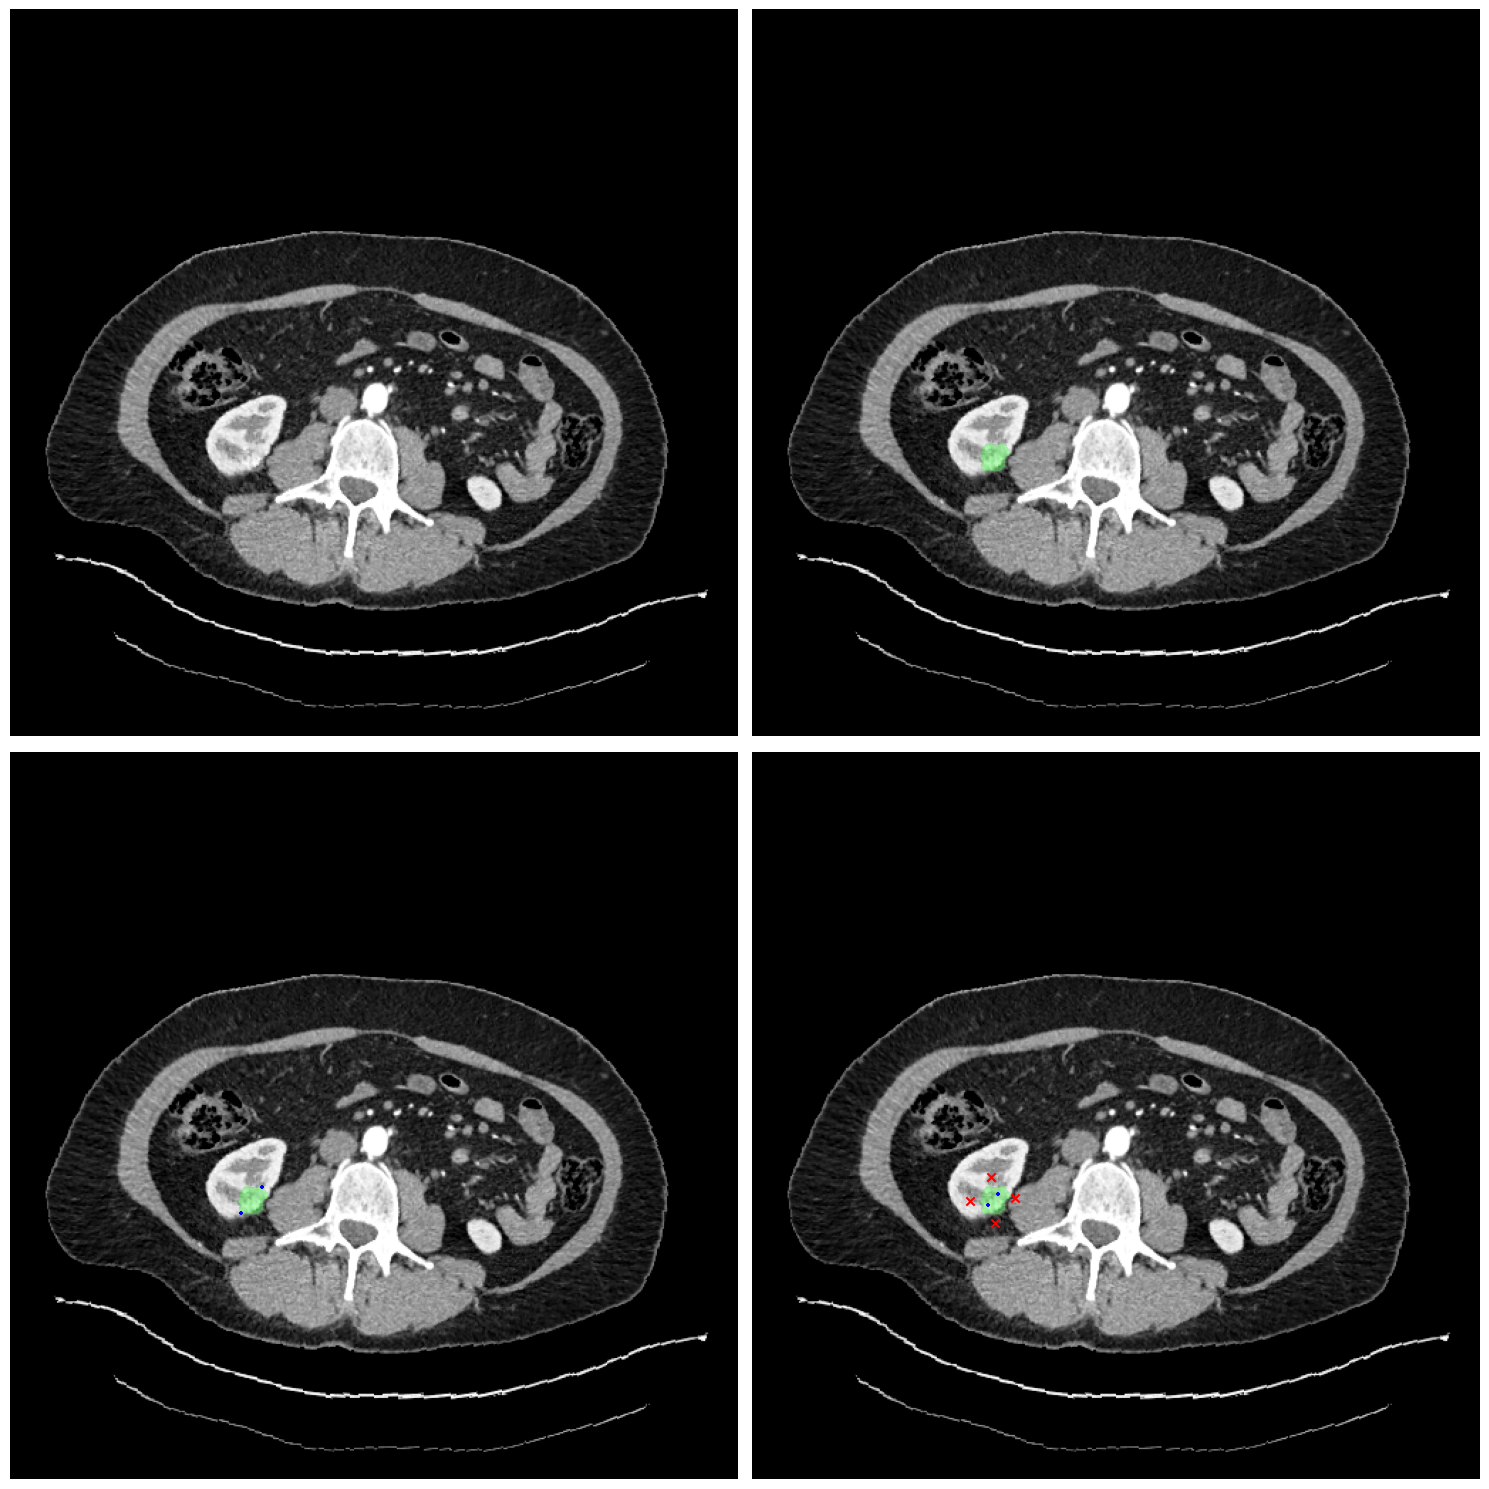

In [50]:
fig_slice, ax_slice = plt.subplots(2, 2, figsize=(15, 15), layout="tight")

dispMin = window_l - (window_w / 2)
dispMax = window_l + (window_w / 2)

ax_index= ax_slice.flatten()

displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0, ax=ax_index[0])
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[1])

# RECIST pts
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[2])
ax_index[2].scatter(recist_pts[0], recist_pts[1], c='b', marker='+', s=6)
ax_index[2].scatter(recist_pts[2], recist_pts[3], c='b', marker='+', s=6)

# actual pts
displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_index[3])
ax_index[3].scatter(recist_iqr_pts[0], recist_iqr_pts[1], c='b', marker='+', s=6)
ax_index[3].scatter(recist_iqr_pts[2], recist_iqr_pts[3], c='b', marker='+', s=6)
ax_index[3].scatter(neg_pts[0], neg_pts[1], c='r', marker='x')
ax_index[3].scatter(neg_pts[2], neg_pts[3], c='r', marker='x')
ax_index[3].scatter(neg_pts[4], neg_pts[5], c='r', marker='x')
ax_index[3].scatter(neg_pts[6], neg_pts[7], c='r', marker='x')

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))

displayCTSegOverlay(scan, mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax)
ax.scatter(recist_iqr_pts[0], recist_iqr_pts[1], c='b', marker='+')
ax.scatter(recist_iqr_pts[2], recist_iqr_pts[3], c='b', marker='+')
ax.scatter(neg_pts[0], neg_pts[1], c='r', marker='x')
ax.scatter(neg_pts[2], neg_pts[3], c='r', marker='x')
ax.scatter(neg_pts[4], neg_pts[5], c='r', marker='x')
ax.scatter(neg_pts[6], neg_pts[7], c='r', marker='x')